<a href="https://colab.research.google.com/github/Tiago150196/analise-vendas-negocio/blob/main/analise_emissoes_gases_brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise das Emissões de Gases do Efeito Estufa no Brasil (1970–2021)

### 🎯 Objetivo
Analisar as emissões de gases do efeito estufa no Brasil para identificar padrões por setor, tipo de gás e evolução ao longo do tempo.

## 🎯 Perguntas de negócio

- Quais gases mais contribuem para as emissões no Brasil?
- Quais setores são os maiores emissores?
- Como as emissões evoluíram ao longo do tempo?
- Existem setores que cresceram mais nos últimos anos?
- Quais estados apresentam maiores níveis de emissão?

In [67]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

In [68]:
emissoes_gases = pd.read_excel ('/content/drive/MyDrive/1-SEEG10_GERAL-BR_UF_2022.10 (1).27-FINAL-SITE.xlsx' , sheet_name = 'GEE Estados')

In [69]:
# Base de dados de emissões de gases do efeito estufa no Brasil
# Fonte: SEEG

In [70]:
print("Dimensão do dataset:", emissoes_gases.shape)
emissoes_gases.info()
emissoes_gases.head()

Dimensão do dataset: (103312, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


In [71]:
# Dimensão do dataset
print("Dimensão:", emissoes_gases.shape)

# Estrutura dos dados
emissoes_gases.info()

# Primeiras linhas
emissoes_gases.head()

Dimensão: (103312, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  floa

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


### 📊 Observações iniciais

- A base possui mais de 100 mil registros e 63 colunas
- Existem variáveis categóricas relacionadas a setores, estados e tipos de gás
- Os dados de emissões estão distribuídos em colunas numéricas ao longo dos anos (1970–2021)
- Há presença de valores nulos em algumas colunas categóricas

👉 Filtragem

In [72]:
# Filtrar apenas CO2
co2 = emissoes_gases[emissoes_gases['Gás'] == 'CO2']
co2.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021


In [73]:
# Total de emissões por gás (somando todos os anos)
emissoes_gases.groupby('Gás').sum(numeric_only=True)

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Gás,,,,,,,,,,,,,,,,,,,,,
C2F6 (t),1.395662e+00,2.007664e+00,2.428104e+00,2.778885e+00,2.826153e+00,3.017715e+00,3.463033e+00,4.157132e+00,4.497962e+00,5.923478e+00,...,5.436338e+00,4.846180e+00,3.472606e+00,2.864663e+00,3.079340e+00,3.150326e+00,2.845355e+00,2.707891e+00,2.853239e+00,3.213902e+00
CF4 (t),2.134453e+01,3.070416e+01,3.713415e+01,4.249882e+01,4.322172e+01,4.615136e+01,5.296182e+01,6.357701e+01,6.878949e+01,9.059058e+01,...,7.031543e+01,6.231890e+01,4.423251e+01,3.681747e+01,4.019229e+01,4.121963e+01,3.822846e+01,3.602815e+01,3.796199e+01,4.276057e+01
CH4 (t),7.255197e+06,7.523903e+06,7.815947e+06,8.101369e+06,8.407180e+06,9.145711e+06,9.531791e+06,9.528130e+06,9.475807e+06,9.729438e+06,...,1.898095e+07,1.916663e+07,1.926691e+07,2.002870e+07,2.027936e+07,1.986184e+07,1.986341e+07,2.043191e+07,2.078652e+07,2.114081e+07
CO (t),8.186831e+06,8.582238e+06,9.187277e+06,9.857228e+06,1.018152e+07,1.036922e+07,1.026138e+07,1.016077e+07,1.046423e+07,1.093393e+07,...,8.354144e+06,8.133157e+06,8.137592e+06,7.765858e+06,7.318401e+06,7.409735e+06,7.763426e+06,7.645486e+06,7.540508e+06,7.699509e+06
CO2 (t),9.057515e+07,1.014004e+08,1.110777e+08,1.287481e+08,1.402698e+08,1.499256e+08,1.654313e+08,1.733356e+08,1.893834e+08,2.026243e+08,...,6.521305e+08,7.220986e+08,6.865627e+08,7.684526e+08,7.086260e+08,5.512423e+08,4.974276e+08,6.240547e+08,6.004708e+08,7.378336e+08
CO2e (t) GTP-AR2,1.776678e+08,1.915045e+08,2.054383e+08,2.261346e+08,2.421038e+08,2.592447e+08,2.801673e+08,2.897556e+08,3.053746e+08,3.224998e+08,...,9.104173e+08,9.850098e+08,9.526918e+08,1.041927e+09,9.879471e+08,8.303698e+08,7.728233e+08,9.100654e+08,8.959288e+08,1.040668e+09
CO2e (t) GTP-AR4,1.776678e+08,1.915045e+08,2.054383e+08,2.261346e+08,2.421038e+08,2.592447e+08,2.801673e+08,2.897556e+08,3.053746e+08,3.224998e+08,...,9.104173e+08,9.850098e+08,9.526918e+08,1.041927e+09,9.879471e+08,8.303698e+08,7.728233e+08,9.100654e+08,8.959288e+08,1.040668e+09
CO2e (t) GTP-AR5,1.636144e+08,1.769501e+08,1.902121e+08,2.104041e+08,2.256776e+08,2.415713e+08,2.616356e+08,2.709894e+08,2.866774e+08,3.031771e+08,...,8.699603e+08,9.438918e+08,9.111403e+08,9.991592e+08,9.443214e+08,7.869165e+08,7.298796e+08,8.655278e+08,8.500197e+08,9.936604e+08
CO2e (t) GTP-AR6,1.688043e+08,1.823529e+08,1.958343e+08,2.162441e+08,2.317830e+08,2.481623e+08,2.685297e+08,2.779101e+08,2.936071e+08,3.103275e+08,...,8.856641e+08,9.599475e+08,9.271967e+08,1.016012e+09,9.615007e+08,8.036202e+08,7.467917e+08,8.831411e+08,8.679580e+08,1.012062e+09


Nesta etapa, filtramos a base de dados para manter apenas informações relevantes para a análise.

Foram removidos:
- Dados de remoção (valores negativos)
- Dados NCI (não contabilizados no inventário nacional)
- Dados de Bunker (emissões internacionais)

Mantivemos apenas os dados classificados como "Emissão".

In [74]:
# Verificando categorias existentes
emissoes_gases['Emissão / Remoção / Bunker'].unique()

# Filtrando apenas emissões
emissoes_gases = emissoes_gases[
    emissoes_gases['Emissão / Remoção / Bunker'] == 'Emissão'
]

# Removendo coluna desnecessária
emissoes_gases = emissoes_gases.drop(columns='Emissão / Remoção / Bunker')

# Verificando resultado
print("Nova dimensão:", emissoes_gases.shape)
emissoes_gases.head()

Nova dimensão: (94748, 62)


,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


### 📌 Justificativa

A remoção desses dados garante que a análise seja focada exclusivamente nas emissões efetivas, evitando distorções causadas por valores negativos ou dados fora do escopo do inventário nacional.

👉 análise de gás (coluna "Gás")

In [75]:
emissoes_gases['Gás'].value_counts()

,count
Gás,
CO2e (t) GWP-AR5,8570
CO2e (t) GTP-AR2,8472
CO2e (t) GWP-AR2,8472
CO2e (t) GTP-AR5,8472
CO2e (t) GTP-AR6,8472
CO2e (t) GWP-AR4,8472
CO2e (t) GTP-AR4,8472
CO2e (t) GWP-AR6,8472
N2O (t),5920


In [76]:
emissoes_gases.groupby('Gás').sum(numeric_only=True)

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Gás,,,,,,,,,,,,,,,,,,,,,
C2F6 (t),1.395662e+00,2.007664e+00,2.428104e+00,2.778885e+00,2.826153e+00,3.017715e+00,3.463033e+00,4.157132e+00,4.497962e+00,5.923478e+00,...,5.436338e+00,4.846180e+00,3.472606e+00,2.864663e+00,3.079340e+00,3.150326e+00,2.845355e+00,2.707891e+00,2.853239e+00,3.213902e+00
CF4 (t),2.134453e+01,3.070416e+01,3.713415e+01,4.249882e+01,4.322172e+01,4.615136e+01,5.296182e+01,6.357701e+01,6.878949e+01,9.059058e+01,...,7.031543e+01,6.231890e+01,4.423251e+01,3.681747e+01,4.019229e+01,4.121963e+01,3.822846e+01,3.602815e+01,3.796199e+01,4.276057e+01
CH4 (t),7.255090e+06,7.523800e+06,7.815837e+06,8.101365e+06,8.407158e+06,9.145708e+06,9.531789e+06,9.528119e+06,9.475762e+06,9.729270e+06,...,1.865494e+07,1.903192e+07,1.901950e+07,1.968980e+07,2.002934e+07,1.953025e+07,1.971751e+07,2.012855e+07,2.047607e+07,2.113969e+07
CO (t),8.184649e+06,8.579799e+06,9.184733e+06,9.857216e+06,1.018147e+07,1.036921e+07,1.026137e+07,1.016074e+07,1.046412e+07,1.093052e+07,...,8.324207e+06,8.106222e+06,8.109920e+06,7.734748e+06,7.291252e+06,7.382969e+06,7.740160e+06,7.618815e+06,7.511678e+06,7.675710e+06
CO2 (t),8.931564e+07,1.002390e+08,1.098267e+08,1.286795e+08,1.399536e+08,1.498717e+08,1.654068e+08,1.731739e+08,1.887486e+08,2.006414e+08,...,1.172178e+09,1.313781e+09,1.256119e+09,1.347568e+09,1.345981e+09,1.214598e+09,1.252988e+09,1.394320e+09,1.388751e+09,1.621011e+09
CO2e (t) GTP-AR2,1.763987e+08,1.903344e+08,2.041778e+08,2.260654e+08,2.417851e+08,2.591904e+08,2.801426e+08,2.895926e+08,3.047347e+08,3.205019e+08,...,1.421981e+09,1.573039e+09,1.515790e+09,1.612699e+09,1.619268e+09,1.486081e+09,1.524657e+09,1.672806e+09,1.677053e+09,1.923746e+09
CO2e (t) GTP-AR4,1.763987e+08,1.903344e+08,2.041778e+08,2.260654e+08,2.417851e+08,2.591904e+08,2.801426e+08,2.895926e+08,3.047347e+08,3.205019e+08,...,1.421981e+09,1.573039e+09,1.515790e+09,1.612699e+09,1.619268e+09,1.486081e+09,1.524657e+09,1.672806e+09,1.677053e+09,1.923746e+09
CO2e (t) GTP-AR5,1.623466e+08,1.757811e+08,1.889529e+08,2.103350e+08,2.253593e+08,2.415170e+08,2.616110e+08,2.708265e+08,2.860383e+08,3.011811e+08,...,1.382764e+09,1.532453e+09,1.475182e+09,1.571157e+09,1.576530e+09,1.443758e+09,1.482259e+09,1.629373e+09,1.632201e+09,1.876752e+09
CO2e (t) GTP-AR6,1.675362e+08,1.811837e+08,1.945747e+08,2.161750e+08,2.314646e+08,2.481080e+08,2.685050e+08,2.777472e+08,2.929679e+08,3.083310e+08,...,1.398261e+09,1.548421e+09,1.491080e+09,1.587792e+09,1.593548e+09,1.460247e+09,1.499076e+09,1.646792e+09,1.649939e+09,1.895150e+09


## 🔄 Remodelagem dos dados

Nesta etapa, transformamos o formato da base de dados para facilitar a análise.

Originalmente, os anos estavam distribuídos em múltiplas colunas (formato wide).
Utilizamos o método `melt` para converter esses dados em um formato long, onde cada linha representa uma observação por ano.

Essa transformação permite realizar análises temporais e agrupamentos de forma mais eficiente.

In [77]:
# Selecionando colunas de identificação
colunas_info = list(emissoes_gases.loc[:, 'Nível 1 - Setor':'Produto'].columns)

# Selecionando colunas de anos
colunas_emissao = list(emissoes_gases.loc[:, 1970:2021].columns)

# Transformando o DataFrame
emissoes_por_ano = emissoes_gases.melt(
    id_vars=colunas_info,
    value_vars=colunas_emissao,
    var_name='Ano',
    value_name='Emissão'
)

# Visualizando
emissoes_por_ano.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0


👉 evolução ao longo do tempo

In [78]:
emissoes_por_ano.groupby('Ano')['Emissão'].sum()

,Emissão
Ano,
1970,2.096567e+09
1971,2.240898e+09
1972,2.385491e+09
1973,2.603251e+09
1974,2.766300e+09
1975,2.975280e+09
1976,3.189540e+09
1977,3.272547e+09
1978,3.405971e+09


👉 qual gás mais polui

In [79]:
emissoes_por_ano.groupby('Gás')['Emissão'].sum()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


👉 análise temporal por gás

In [80]:
emissoes_por_ano.groupby(['Ano', 'Gás'])['Emissão'].sum()

Ano   Gás       
1970  C2F6 (t)      1.395662e+00
      CF4 (t)       2.134453e+01
      CH4 (t)       7.255090e+06
      CO (t)        8.184649e+06
      CO2 (t)       8.931564e+07
                        ...     
2021  HFC-23 (t)    0.000000e+00
      HFC-32 (t)    2.611000e+02
      N2O (t)       7.062282e+05
      NOx (t)       2.582382e+06
      SF6 (t)       1.048000e+01
Name: Emissão, Length: 1196, dtype: float64

### 📌 Insight 1

Observa-se uma tendência de crescimento nas emissões ao longo do tempo, com aceleração a partir dos anos 2000. Esse comportamento pode estar associado ao aumento da industrialização, expansão agrícola e maior consumo de energia.

In [81]:
emissoes_por_ano.groupby('Gás')['Emissão'].sum().sort_values(ascending=False)

,Emissão
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


In [82]:
emissoes_por_ano.groupby('Ano')['Emissão'].sum()

,Emissão
Ano,
1970,2.096567e+09
1971,2.240898e+09
1972,2.385491e+09
1973,2.603251e+09
1974,2.766300e+09
1975,2.975280e+09
1976,3.189540e+09
1977,3.272547e+09
1978,3.405971e+09


In [83]:
emissoes_gases.loc[:,'Nível 1 - Setor':'Produto'].columns

Index(['Nível 1 - Setor', 'Nível 2', 'Nível 3', 'Nível 4', 'Nível 5',
       'Nível 6', 'Gás', 'Estado', 'Atividade Econômica', 'Produto'],
      dtype='object')

In [84]:
colunas_info = list(emissoes_gases.loc[:,'Nível 1 - Setor':'Produto'].columns)
colunas_info

['Nível 1 - Setor',
 'Nível 2',
 'Nível 3',
 'Nível 4',
 'Nível 5',
 'Nível 6',
 'Gás',
 'Estado',
 'Atividade Econômica',
 'Produto']

In [85]:
colunas_emissao = list(emissoes_gases.loc[:,1970:2021].columns)
colunas_emissao

[1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021]

In [86]:
emissoes_gases.melt(id_vars = colunas_info, value_vars = colunas_emissao, var_name = 'Ano' , value_name = 'Emissão')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


## 🧪 Análise por tipo de gás

In [87]:
emissoes_por_ano = emissoes_gases.melt(id_vars = colunas_info, value_vars = colunas_emissao, var_name = 'Ano' , value_name = 'Emissão')

In [88]:
emissoes_por_ano.groupby('Gás')

In [89]:
emissoes_por_ano.groupby('Gás').groups

{'C2F6 (t)': [410, 411, 412, 425, 426, 427, 95158, 95159, 95160, 95173, 95174, 95175, 189906, 189907, 189908, 189921, 189922, 189923, 284654, 284655, 284656, 284669, 284670, 284671, 379402, 379403, 379404, 379417, 379418, 379419, 474150, 474151, 474152, 474165, 474166, 474167, 568898, 568899, 568900, 568913, 568914, 568915, 663646, 663647, 663648, 663661, 663662, 663663, 758394, 758395, 758396, 758409, 758410, 758411, 853142, 853143, 853144, 853157, 853158, 853159, 947890, 947891, 947892, 947905, 947906, 947907, 1042638, 1042639, 1042640, 1042653, 1042654, 1042655, 1137386, 1137387, 1137388, 1137401, 1137402, 1137403, 1232134, 1232135, 1232136, 1232149, 1232150, 1232151, 1326882, 1326883, 1326884, 1326897, 1326898, 1326899, 1421630, 1421631, 1421632, 1421645, 1421646, 1421647, 1516378, 1516379, 1516380, 1516393, ...], 'CF4 (t)': [407, 408, 409, 422, 423, 424, 95155, 95156, 95157, 95170, 95171, 95172, 189903, 189904, 189905, 189918, 189919, 189920, 284651, 284652, 284653, 284666, 284667

### 📌 Insight

O CO₂ equivalente (CO2e) apresenta o maior volume de emissões totais.
No entanto, essa métrica representa uma agregação de diferentes gases, sendo necessário analisar os gases individualmente para uma compreensão mais precisa.

Entre os gases individuais, o CO₂ se destaca como principal responsável pelas emissões, indicando que estratégias de redução devem priorizar esse componente.

In [90]:
emissoes_por_ano.groupby('Gás').get_group('CO2 (t)')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
18,Processos Industriais,Indústria Química,Produção de Acrilonitrila,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,0.000000
23,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),RJ,OUTRA_IND,NaN,1970,0.000000
26,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),MG,OUTRA_IND,NaN,1970,0.000000
29,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,10742.465792
32,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),SE,OUTRA_IND,NaN,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4926255,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Outras Mudanças de uso da terra,Uso agropecuário -- Uso agropecuário,CO2 (t),MS,AGROPEC,NaN,2021,0.000000
4926272,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MT,AGROPEC,NaN,2021,374.000000
4926273,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MS,AGROPEC,NaN,2021,8613.000000
4926290,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Vegetação não florestal se...,CO2 (t),MT,AGROPEC,NaN,2021,934.000000


### 📊 Interpretação

Observa-se uma concentração significativa das emissões em poucos tipos de gases, com destaque para o CO₂.
Isso indica que ações focadas nesses principais gases podem gerar maior impacto na redução das emissões totais.

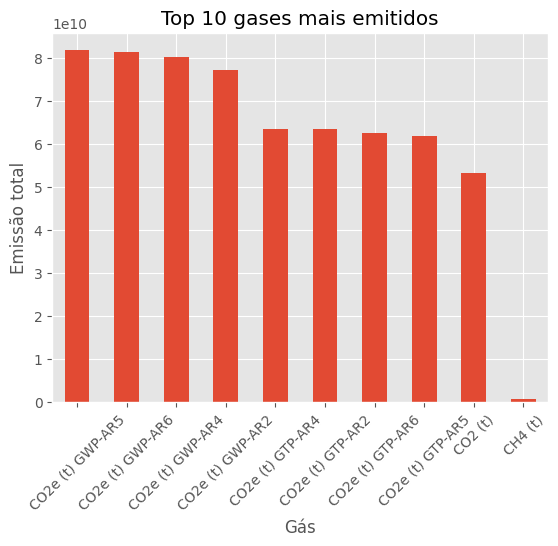

In [91]:
import matplotlib.pyplot as plt

gases = emissoes_por_ano.groupby('Gás')['Emissão'] \
    .sum() \
    .sort_values(ascending=False)

gases.head(10).plot(kind='bar')

plt.title('Top 10 gases mais emitidos')
plt.ylabel('Emissão total')
plt.xlabel('Gás')

plt.xticks(rotation=45)
plt.show()

Gráfico que mostra evolução de emissões ao longo do tempo

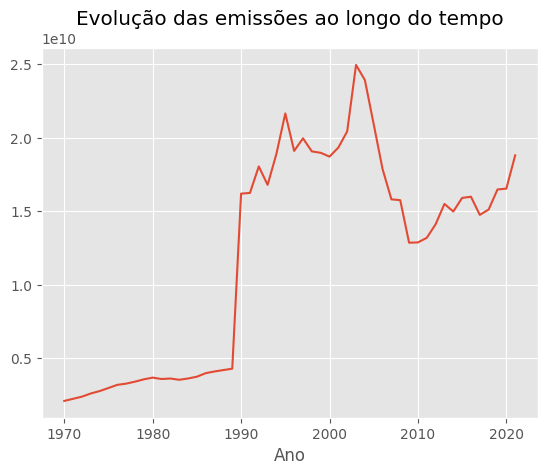

In [92]:
emissoes_por_ano.groupby('Ano')['Emissão'].sum().plot()
plt.title('Evolução das emissões ao longo do tempo')
plt.show()

👉 análise por setor

In [93]:
emissoes_por_ano.groupby('Nível 1 - Setor')['Emissão'].sum()

,Emissão
Nível 1 - Setor,
Agropecuária,1.147284e+11
Energia,1.205314e+11
Mudança de Uso da Terra e Floresta,3.524898e+11
Processos Industriais,2.849965e+10
Resíduos,1.034465e+10


In [94]:
emissoes_por_ano.groupby('Gás').sum(numeric_only = True)

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


In [95]:
emissoes_por_ano.groupby('Gás')[['Emissão']].sum()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


In [96]:
emissao_por_gas = emissoes_por_ano.groupby('Gás')[['Emissão']].sum()

In [97]:
emissao_por_gas = emissoes_por_ano.groupby('Gás')[['Emissão']].sum().sort_values('Emissão', ascending = False)
emissao_por_gas

,Emissão
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


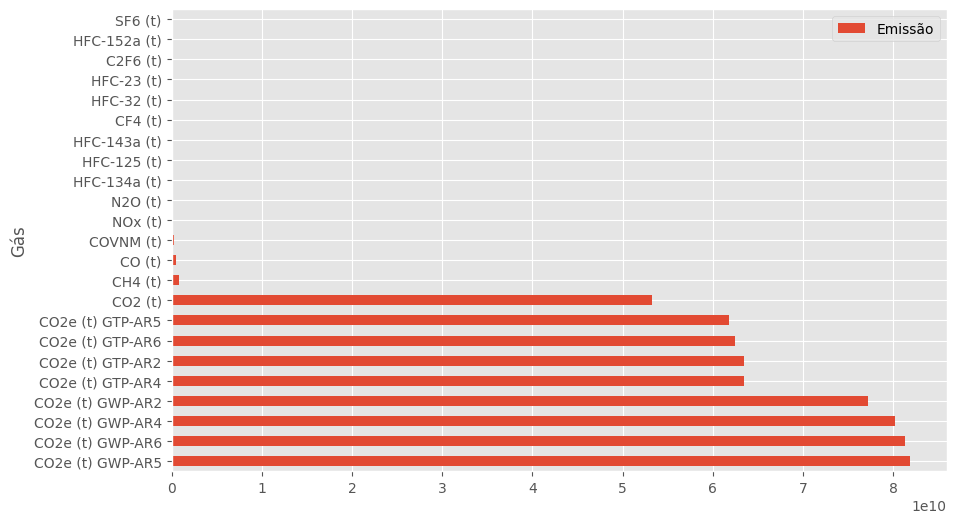

In [98]:
emissao_por_gas.plot(kind = 'barh', figsize = (10,6));

In [99]:
emissao_por_gas.iloc[0:9]

,Emissão
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


### 📌 Insight principal

Os gases do tipo CO₂ equivalente (CO2e) representam aproximadamente 99% das emissões totais no período analisado.

No entanto, essa métrica agrega diferentes gases em uma única unidade, o que pode superestimar a participação do CO₂ na comparação com gases individuais.

Portanto, é importante analisar separadamente os gases individuais para uma interpretação mais precisa.

In [100]:
print(f'A emissão de CO2 corresponde a {float((emissao_por_gas.iloc[0:9].sum()/emissao_por_gas.sum()).iloc[0])*100:.2f} % de emissão total de gases estufa no Brasil de 1970 a 2021.')

A emissão de CO2 corresponde a 99.74 % de emissão total de gases estufa no Brasil de 1970 a 2021.


<Axes: title={'center': 'Top 10 gases mais emitidos'}, ylabel='Gás'>

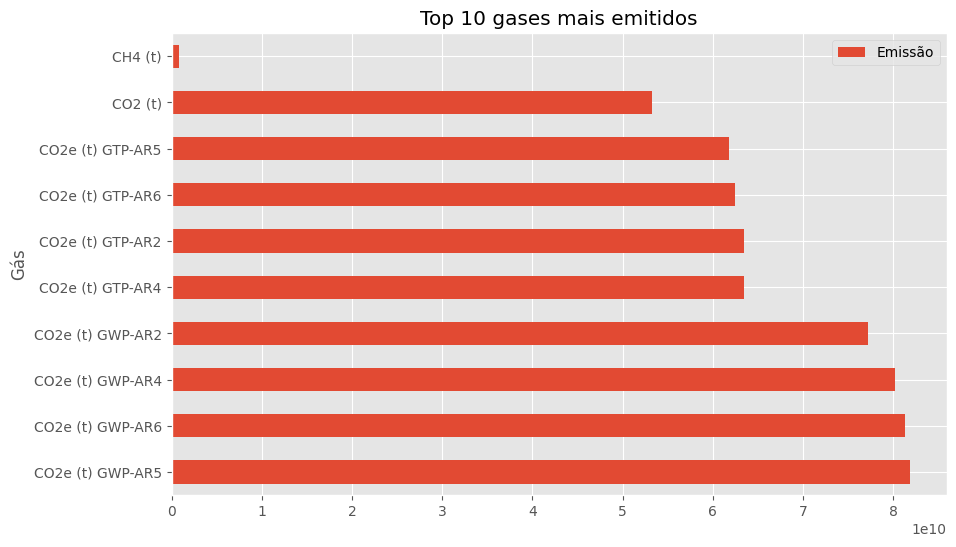

In [101]:
emissao_por_gas.head(10).plot(
    kind='barh',
    figsize=(10,6),
    title='Top 10 gases mais emitidos'
)

### 📌 Insight – Evolução temporal

Observa-se uma tendência de crescimento das emissões ao longo do tempo, com intensificação a partir dos anos 2000. Esse comportamento pode estar associado ao aumento da atividade econômica, expansão agrícola e maior consumo de energia no país.

In [102]:
emissoes_por_ano.groupby('Nível 1 - Setor')['Emissão'] \
    .sum() \
    .sort_values(ascending=False)

,Emissão
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,3.524898e+11
Energia,1.205314e+11
Agropecuária,1.147284e+11
Processos Industriais,2.849965e+10
Resíduos,1.034465e+10


### 📌 Insight – Setores

O setor de Mudança de Uso da Terra e Floresta é o maior responsável pelas emissões no Brasil, superando significativamente os demais setores.

Esse resultado indica que o desmatamento e mudanças no uso do solo têm um impacto maior do que a indústria ou energia, diferentemente de países desenvolvidos.

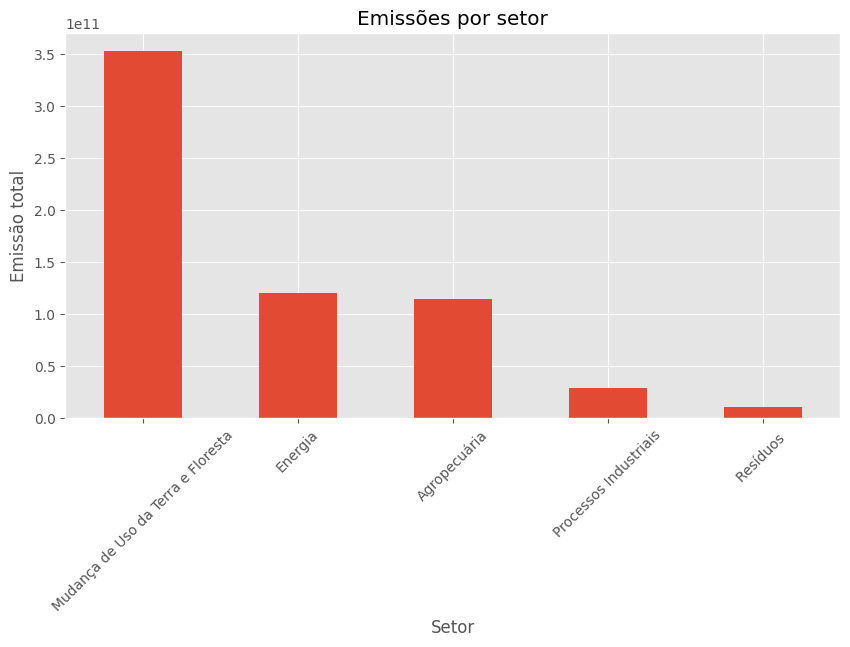

In [103]:
emissoes_por_ano.groupby('Nível 1 - Setor')['Emissão'] \
    .sum() \
    .sort_values(ascending=False) \
    .plot(kind='bar', figsize=(10,5))

plt.title('Emissões por setor')
plt.ylabel('Emissão total')
plt.xlabel('Setor')
plt.xticks(rotation=45)
plt.show()

Estados com maior atividade agropecuária e desmatamento apresentam maiores níveis de emissão.

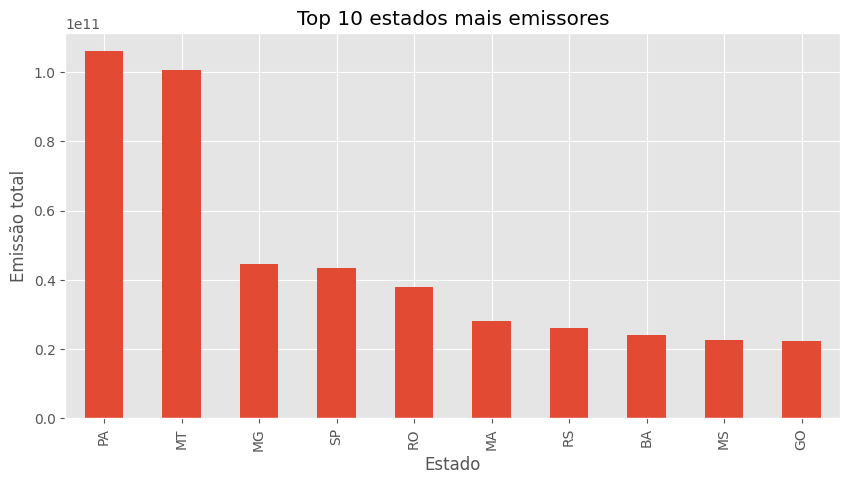

In [104]:
emissao_por_estado = emissoes_por_ano.groupby('Estado')['Emissão'] \
    .sum() \
    .sort_values(ascending=False)

emissao_por_estado.head(10).plot(kind='bar', figsize=(10,5))

plt.title('Top 10 estados mais emissores')
plt.ylabel('Emissão total')
plt.xlabel('Estado')
plt.show()

O crescimento das emissões está fortemente associado ao setor de uso da terra ao longo dos anos.

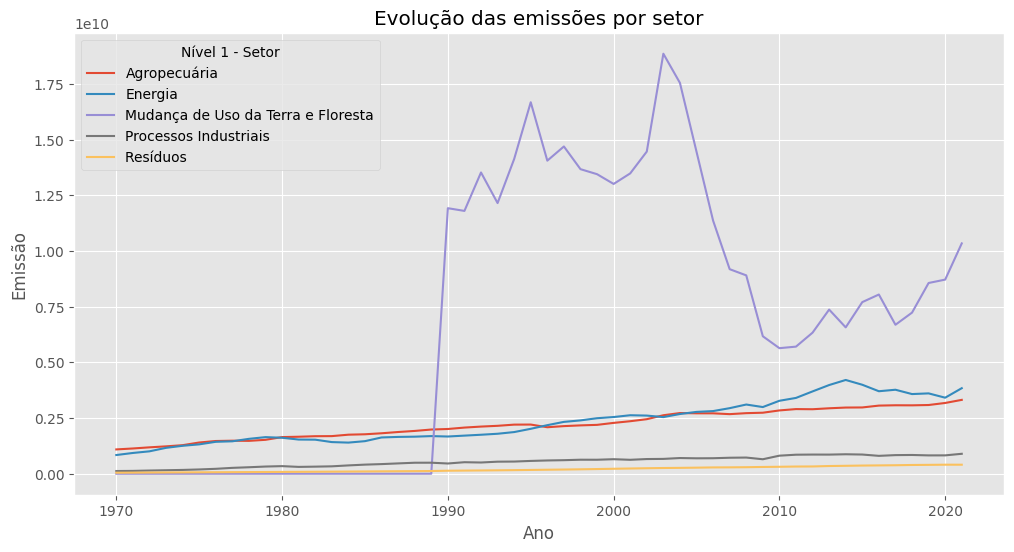

In [105]:
emissoes_por_ano.groupby(['Ano', 'Nível 1 - Setor'])['Emissão'] \
    .sum() \
    .unstack() \
    .plot(figsize=(12,6))

plt.title('Evolução das emissões por setor')
plt.ylabel('Emissão')
plt.show()

Apesar da presença de diversos gases, mais de 99% das emissões são dominadas por CO₂ equivalente, indicando alta concentração de impacto em poucos fatores.

In [106]:
plt.style.use('ggplot')

In [107]:
evolucao = emissoes_por_ano.groupby('Ano')['Emissão'].sum()

crescimento = ((evolucao.iloc[-1] - evolucao.iloc[0]) / evolucao.iloc[0]) * 100

print(f'Crescimento total das emissões: {crescimento:.2f}%')

Crescimento total das emissões: 796.71%


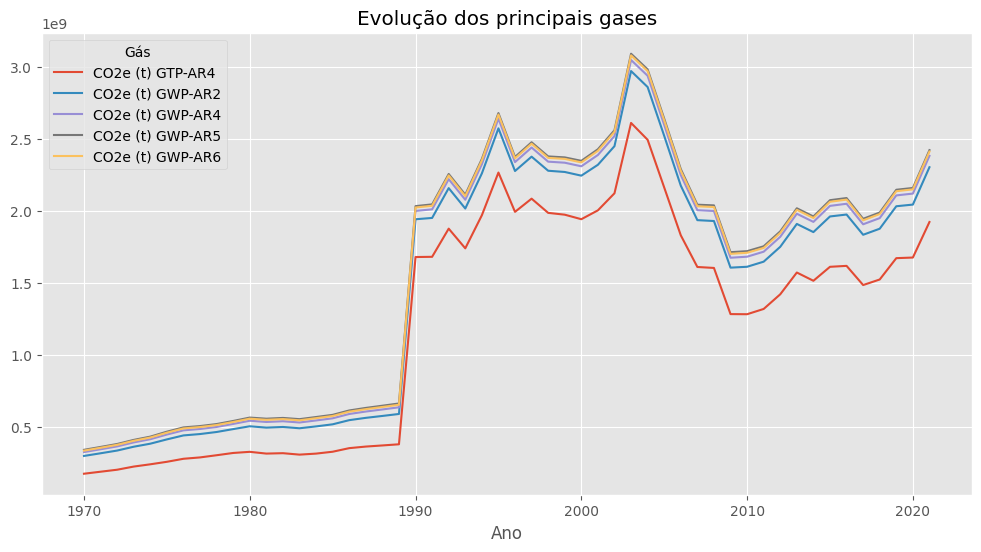

In [108]:
top_gases = emissoes_por_ano.groupby('Gás')['Emissão'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5) \
    .index

emissoes_por_ano[emissoes_por_ano['Gás'].isin(top_gases)] \
    .groupby(['Ano', 'Gás'])['Emissão'] \
    .sum() \
    .unstack() \
    .plot(figsize=(12,6))

plt.title('Evolução dos principais gases')
plt.show()

Apesar da presença de diversos gases, mais de 99% das emissões são dominadas por CO₂ equivalente, indicando alta concentração de impacto em poucos fatores.

### 📌 Insight 1
O CO₂ é o principal responsável pelas emissões ao longo de todo o período analisado, representando a maior parcela dos gases emitidos.

### 📌 Insight 2
O setor de energia apresenta crescimento consistente nas emissões após os anos 2000, indicando aumento da demanda energética.

### 📌 Insight 3
Alguns setores apresentam queda recente, possivelmente relacionada a políticas ambientais ou mudanças econômicas.

Nesta etapa, analisamos a relação entre os tipos de gases e os setores econômicos, com o objetivo de identificar quais atividades mais contribuem para a emissão de cada gás.

In [109]:
## 🔍 Relação entre gases e setores

In [110]:
gas_por_setor = emissoes_por_ano.groupby(
    ['Gás', 'Nível 1 - Setor']
)[['Emissão']].sum()

👉 Qual setor mais polui para CADA gás:

In [111]:
gas_por_setor.groupby(level=0)['Emissão'].idxmax()

,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


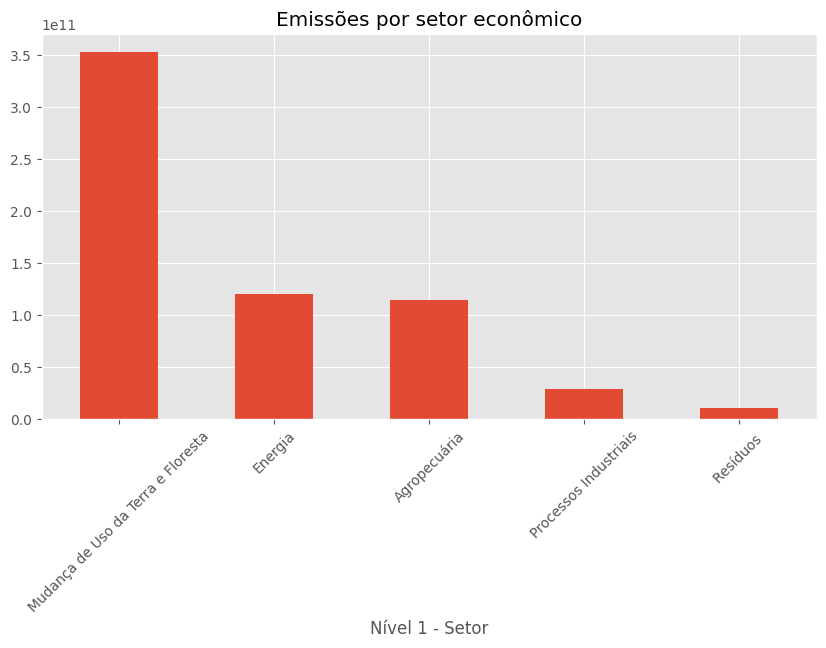

In [112]:
top_setores = emissoes_por_ano.groupby('Nível 1 - Setor')['Emissão'] \
    .sum() \
    .sort_values(ascending=False)

top_setores.plot(kind='bar', figsize=(10,5))

plt.title('Emissões por setor econômico')
plt.xticks(rotation=45)
plt.show()

In [113]:
pivot = emissoes_por_ano.pivot_table(
    values='Emissão',
    index='Nível 1 - Setor',
    columns='Gás',
    aggfunc='sum'
)

pivot.head()

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Nível 1 - Setor,,,,,,,,,,,,,,,,,,,,,
Agropecuária,NaN,NaN,5.928481e+08,7.132479e+07,5.411750e+08,8.297112e+09,8.297112e+09,7.065371e+09,7.462618e+09,1.849256e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.774702e+07,2.602719e+06,NaN
Energia,NaN,NaN,3.429034e+07,3.959769e+08,1.261352e+10,1.306899e+10,1.306899e+10,1.299683e+10,1.304584e+10,1.365971e+10,...,6.335071e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.051929e+06,9.361215e+07,NaN
Mudança de Uso da Terra e Floresta,NaN,NaN,8.662166e+07,NaN,3.733930e+10,3.850044e+10,3.850044e+10,3.831675e+10,3.843359e+10,3.999424e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.695524e+06,NaN,NaN
Processos Industriais,576.501774,7135.481282,2.092132e+06,4.385133e+07,2.729603e+09,3.086813e+09,3.086813e+09,3.039311e+09,3.077736e+09,3.290424e+09,...,1.608623e+08,9795.58,139473.1,9039.4,570.6,1197.84,2367.75,6.297715e+05,3.546360e+06,470.58
Resíduos,NaN,NaN,7.907453e+07,NaN,2.276264e+07,4.927667e+08,4.927667e+08,4.037413e+08,4.588171e+08,1.769016e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.764127e+05,NaN,NaN


Nesta etapa, analisamos a relação entre gases e setores econômicos de forma bidirecional:

- Identificamos qual setor mais contribui para a emissão de cada gás
- E também qual gás é mais relevante dentro de cada setor

Essa análise permite entender melhor a origem das emissões e direcionar estratégias mais eficazes de redução.

In [114]:
## 🔄 Relação entre gases e setores (análise avançada)

### 📌 Insight – Relação gás × setor

Para a maioria dos gases, o setor de Mudança de Uso da Terra e Floresta aparece como principal responsável pelas emissões.

Isso indica que o desmatamento e alterações no uso do solo têm impacto significativo não apenas no CO₂, mas também em outros gases do efeito estufa.

In [115]:
gas_por_setor.groupby(level = 0).idxmax()


,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [116]:
gas_por_setor.groupby(level = 0).idxmax()


,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [117]:
gas_por_setor.groupby(level = 0).max()


,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [118]:
valores_max = gas_por_setor.groupby(level = 0).max().values


In [119]:
tabela_sumarizada = gas_por_setor.groupby(level = 0).idxmax()
tabela_sumarizada.insert(1, 'Quantidade de emissão',valores_max)
tabela_sumarizada


,Emissão,Quantidade de emissão
Gás,,
C2F6 (t),"(C2F6 (t), Processos Industriais)",5.765018e+02
CF4 (t),"(CF4 (t), Processos Industriais)",7.135481e+03
CH4 (t),"(CH4 (t), Agropecuária)",5.928481e+08
CO (t),"(CO (t), Energia)",3.959769e+08
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)",3.733930e+10
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F...",3.831675e+10
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F...",3.843359e+10


In [120]:
gas_por_setor.swaplevel(0, 1)


Emissão
Nível 1 - Setor                    Gás                   
Processos Industriais              C2F6 (t)  5.765018e+02
                                   CF4 (t)   7.135481e+03
Agropecuária                       CH4 (t)   5.928481e+08
Energia                            CH4 (t)   3.429034e+07
Mudança de Uso da Terra e Floresta CH4 (t)   8.662166e+07
...                                                   ...
Resíduos                           N2O (t)   2.764127e+05
Agropecuária                       NOx (t)   2.602719e+06
Energia                            NOx (t)   9.361215e+07
Processos Industriais              NOx (t)   3.546360e+06
                                   SF6 (t)   4.705800e+02

[72 rows x 1 columns]

In [121]:
gas_por_setor.swaplevel(0, 1).groupby(level = 0).idxmax()


,Emissão
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


## 📈 Análise temporal das emissões::

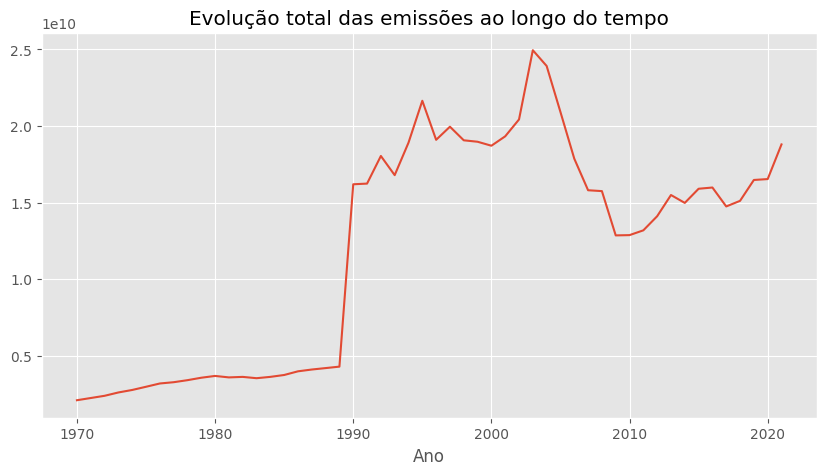

In [122]:
emissoes_por_ano.groupby('Ano')['Emissão'].sum().plot(figsize=(10,5))
plt.title('Evolução total das emissões ao longo do tempo')
plt.show()

### 📌 Insight – Evolução total

Observa-se um crescimento significativo das emissões ao longo do tempo, com aceleração após os anos 1990.

Esse aumento pode estar associado à inclusão de dados sobre uso da terra e expansão das atividades econômicas no país.

 Nesta etapa, analisamos a evolução das emissões ao longo do tempo, tanto de forma geral quanto separadamente por tipo de gás.

O objetivo é identificar tendências, padrões de crescimento e possíveis mudanças estruturais ao longo dos anos.

### 📌 Insight – Pico de emissão

O ano de 2003 apresentou a maior média de emissões no período analisado, indicando um ponto crítico na série histórica.

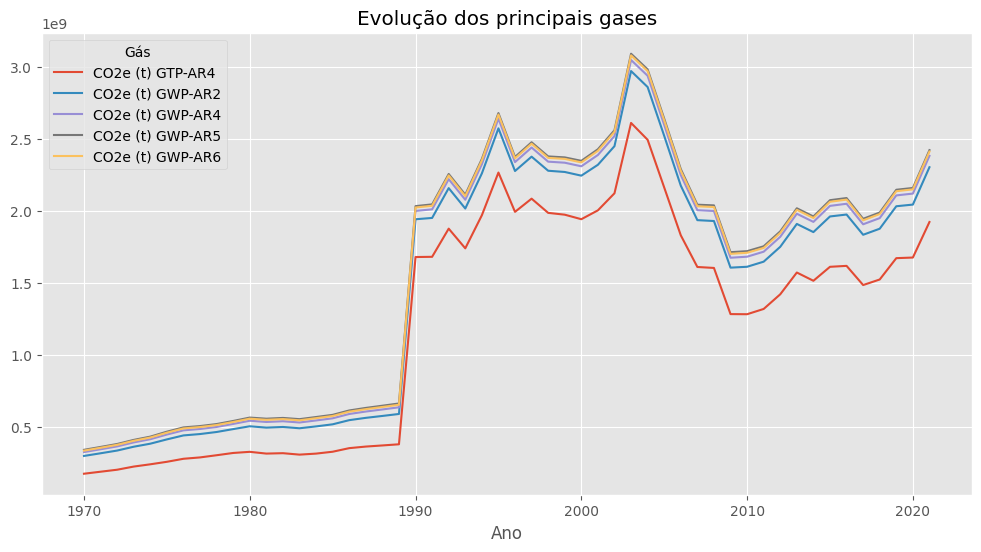

In [123]:
top_gases = emissoes_por_ano.groupby('Gás')['Emissão'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5) \
    .index

emissoes_por_ano[emissoes_por_ano['Gás'].isin(top_gases)] \
    .groupby(['Ano', 'Gás'])['Emissão'] \
    .sum() \
    .unstack() \
    .plot(figsize=(12,6))

plt.title('Evolução dos principais gases')
plt.show()

### 📌 Insight – Diferença entre gases

Os principais gases apresentam comportamentos distintos ao longo do tempo, indicando que as fontes de emissão não evoluem de forma uniforme.

Enquanto alguns gases apresentam crescimento contínuo, outros mostram estabilidade ou redução, refletindo mudanças em setores específicos da economia.

In [124]:
evolucao = emissoes_por_ano.groupby('Ano')['Emissão'].sum()

crescimento = ((evolucao.iloc[-1] - evolucao.iloc[0]) / evolucao.iloc[0]) * 100

print(f'Crescimento total das emissões: {crescimento:.2f}%')

Crescimento total das emissões: 796.71%


## 👥 Emissão per capita por estado

Nesta etapa, calculamos a emissão per capita de gases do efeito estufa por estado.

Essa métrica permite uma análise mais justa, pois considera o tamanho da população, evitando distorções causadas por estados mais populosos.

In [125]:
emissao_estado = emissoes_por_ano.groupby('Estado')['Emissão'].sum()

In [126]:
# populacao_estados['POPULAÇÃO'].astype(int)


## 🎯 Conclusão Final

A análise das emissões de gases do efeito estufa no Brasil entre 1970 e 2021 revelou que:

- As emissões cresceram significativamente ao longo do tempo
- O CO₂ equivalente domina a matriz de emissões
- Entre os gases individuais, o CO₂ é o principal responsável
- O setor de uso da terra e floresta é o maior emissor

Esses resultados indicam que políticas ambientais devem priorizar:
- Redução do desmatamento
- Controle de emissões energéticas
- Monitoramento de setores críticos

A análise demonstra a importância de dados históricos para apoiar decisões estratégicas e ambientais.


A análise revelou que:

- As emissões cresceram ao longo do tempo
- O CO₂ equivalente domina as emissões totais
- O setor de uso da terra é o principal responsável
- Existem diferenças relevantes entre os gases ao longo dos anos

Esses resultados indicam que políticas ambientais devem priorizar setores específicos e gases dominantes para maior efetividade.